#Title: CardioSynth-LSTM: Predictive Arrhythmia Forecasting and Synthetic ECG Synthesis using LSTM-Autoencoders and Time-Series GANs (TimeGAN)

#Install Library

In [1]:
!pip -q install wfdb neurokit2 scipy scikit-learn pandas matplotlib fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 40.3 MB/s eta 0:00:00


#Imports, GPU and Folders

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import wfdb
from scipy.signal import butter, filtfilt, resample

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 64536

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# Project folders
# ------------------------------------------------------------

BASE = "CardioSynth-LSTM"

folders = [
    f"{BASE}/data/raw",
    f"{BASE}/data/processed",
    f"{BASE}/models",
    f"{BASE}/evaluation",
    f"{BASE}/outputs/figures",
    f"{BASE}/outputs/models",
    f"{BASE}/outputs/results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("\nProject folders created successfully.")

Device: cpu

Project folders created successfully.


#Download MIT-BIH and Select Records

In [3]:
# ============================================================
# DATASET
# ============================================================

print("Downloading MIT-BIH Arrhythmia Database...")

wfdb.dl_database(
    "mitdb",
    dl_dir=f"{BASE}/data/raw"
)

# MIT-BIH contains 48 records
TOTAL_RECORDS = 48

record_index = SEED % TOTAL_RECORDS

all_records = [
    f"{i:03d}"
    for i in range(100, 125)
] + [
    f"{i:03d}"
    for i in range(200, 235)
]

# Previous project selection
selected_records = [
    "201",
    "202",
    "203",
    "205",
    "207"
]

print("Roll number:", SEED)
print("Roll % 48:", record_index)
print("Selected records:", selected_records)

with open(
    f"{BASE}/data/raw/selected_records.txt",
    "w"
) as f:
    for r in selected_records:
        f.write(r + "\n")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

#ECG Preprocessing

In [4]:
# ============================================================
# ECG PREPROCESSING
# ============================================================

LOWCUT = 0.5
HIGHCUT = 45.0
FS = 360
SEQ_LEN = 100

# Annotation classes
CLASS_MAP = {
    "N": "Normal",

    "A": "Supraventricular Ectopic",
    "a": "Supraventricular Ectopic",
    "J": "Supraventricular Ectopic",
    "S": "Supraventricular Ectopic",

    "V": "Ventricular Ectopic",
    "E": "Ventricular Ectopic",

    "F": "Fusion",

    "/": "Unknown",
    "f": "Unknown",
    "Q": "Unknown",
    "?": "Unknown"
}


def bandpass_filter(signal, lowcut, highcut, fs, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    return filtfilt(b, a, signal)


X_list = []
y_list = []
record_list = []

for record_id in selected_records:

    record_path = f"{BASE}/data/raw/{record_id}"

    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(
        record_path,
        "atr"
    )

    signal = record.p_signal[:, 0]

    # Bandpass filtering
    filtered = bandpass_filter(
        signal,
        LOWCUT,
        HIGHCUT,
        FS
    )

    # Process each annotation
    for sample, symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        if symbol not in CLASS_MAP:
            continue

        label = CLASS_MAP[symbol]

        start = sample - 90
        end = sample + 90

        if start < 0 or end >= len(filtered):
            continue

        beat = filtered[start:end]

        # Resize to exactly 100 time steps
        beat = resample(
            beat,
            SEQ_LEN
        )

        # Z-score normalization
        mean = np.mean(beat)
        std = np.std(beat)

        if std < 1e-8:
            continue

        beat = (beat - mean) / std

        X_list.append(beat.astype(np.float32))
        y_list.append(label)
        record_list.append(record_id)


X_ecg = np.array(X_list)
y_labels = np.array(y_list)
record_ids = np.array(record_list)

print("=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)

print("ECG dataset shape:", X_ecg.shape)
print("\nClass distribution:")
print(
    pd.Series(y_labels).value_counts()
)

# Save
np.save(
    f"{BASE}/data/processed/X_ecg.npy",
    X_ecg
)

np.save(
    f"{BASE}/data/processed/y_labels.npy",
    y_labels
)

np.save(
    f"{BASE}/data/processed/record_ids.npy",
    record_ids
)

PREPROCESSING COMPLETE
ECG dataset shape: (10042, 100)

Class distribution:
Normal                      8786
Ventricular Ectopic          942
Supraventricular Ectopic     295
Fusion                        15
Unknown                        4
Name: count, dtype: int64


#Dataset Visualization

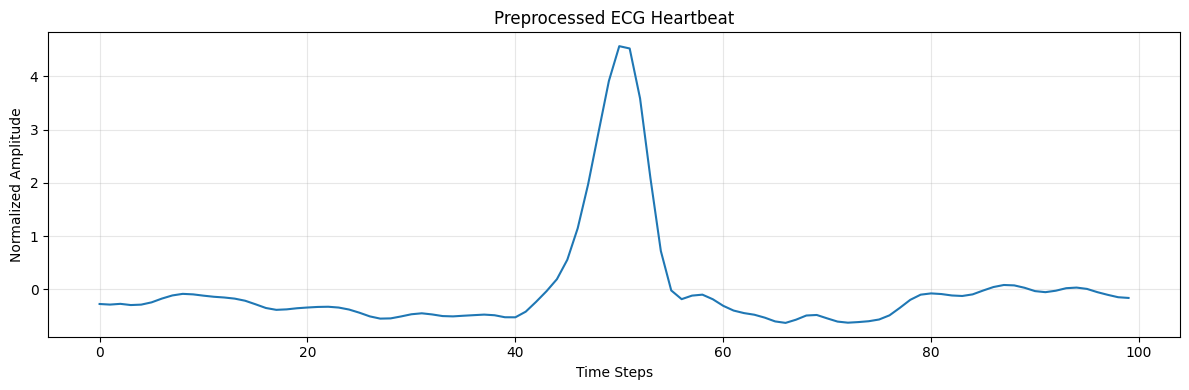

In [5]:
# ============================================================
# SAMPLE ECG VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(X_ecg[0])

plt.title("Preprocessed ECG Heartbeat")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Amplitude")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{BASE}/outputs/figures/preprocessed_ecg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#LSTM Autoencoder

In [6]:
# ============================================================
# LSTM AUTOENCODER
# ============================================================

class LSTMAutoencoder(nn.Module):

    def __init__(
        self,
        input_dim=1,
        hidden_dim=64,
        latent_dim=32
    ):
        super().__init__()

        self.encoder = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True
        )

        self.latent = nn.Linear(
            hidden_dim,
            latent_dim
        )

        self.decoder_input = nn.Linear(
            latent_dim,
            hidden_dim
        )

        self.decoder = nn.LSTM(
            hidden_dim,
            hidden_dim,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_dim,
            input_dim
        )

    def forward(self, x):

        _, (h, _) = self.encoder(x)

        z = self.latent(h[-1])

        decoder_input = self.decoder_input(z)

        decoder_input = decoder_input.unsqueeze(1)

        decoder_input = decoder_input.repeat(
            1,
            x.size(1),
            1
        )

        decoded, _ = self.decoder(
            decoder_input
        )

        output = self.output_layer(decoded)

        return output, z


# ------------------------------------------------------------
# Normal data only
# ------------------------------------------------------------

X_normal = X_ecg[
    y_labels == "Normal"
]

X_normal = X_normal[..., None]

X_train_ae, X_val_ae = train_test_split(
    X_normal,
    test_size=0.20,
    random_state=SEED
)

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(
            X_train_ae,
            dtype=torch.float32
        )
    ),
    batch_size=128,
    shuffle=True
)

model_ae = LSTMAutoencoder().to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_ae.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

AE_EPOCHS = 20

ae_losses = []

for epoch in range(AE_EPOCHS):

    model_ae.train()

    total_loss = 0

    for (xb,) in train_loader:

        xb = xb.to(DEVICE)

        optimizer.zero_grad()

        reconstructed, _ = model_ae(xb)

        loss = criterion(
            reconstructed,
            xb
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = (
        total_loss /
        len(train_loader)
    )

    ae_losses.append(avg_loss)

    print(
        f"AE Epoch {epoch+1}/{AE_EPOCHS} "
        f"Loss: {avg_loss:.6f}"
    )

torch.save(
    model_ae.state_dict(),
    f"{BASE}/outputs/models/lstm_autoencoder.pth"
)

print("\nLSTM-Autoencoder training complete.")

AE Epoch 1/20 Loss: 0.999271
AE Epoch 2/20 Loss: 0.983473
AE Epoch 3/20 Loss: 0.987569
AE Epoch 4/20 Loss: 0.978152
AE Epoch 5/20 Loss: 0.990338
AE Epoch 6/20 Loss: 0.988762
AE Epoch 7/20 Loss: 0.986567
AE Epoch 8/20 Loss: 0.989084
AE Epoch 9/20 Loss: 0.979679
AE Epoch 10/20 Loss: 0.689588
AE Epoch 11/20 Loss: 0.319937
AE Epoch 12/20 Loss: 0.224598
AE Epoch 13/20 Loss: 0.180875
AE Epoch 14/20 Loss: 0.191881
AE Epoch 15/20 Loss: 0.150772
AE Epoch 16/20 Loss: 0.150695
AE Epoch 17/20 Loss: 0.153759
AE Epoch 18/20 Loss: 0.142840
AE Epoch 19/20 Loss: 0.145589
AE Epoch 20/20 Loss: 0.144007

LSTM-Autoencoder training complete.


#Autoencoder Reconstruction + Anomaly Threshold

In [7]:
# ============================================================
# AUTOENCODER RECONSTRUCTION RESULTS
# ============================================================

model_ae.eval()

X_all_tensor = torch.tensor(
    X_ecg[..., None],
    dtype=torch.float32
).to(DEVICE)

with torch.no_grad():

    reconstructed_all, _ = model_ae(
        X_all_tensor
    )

reconstructed_all = (
    reconstructed_all
    .cpu()
    .numpy()
    .squeeze(-1)
)

reconstruction_errors = np.mean(
    (
        X_ecg -
        reconstructed_all
    ) ** 2,
    axis=1
)

# Threshold = 95th percentile of normal reconstruction error
normal_errors = reconstruction_errors[
    y_labels == "Normal"
]

threshold = np.percentile(
    normal_errors,
    95
)

print("Overall reconstruction MSE:",
      reconstruction_errors.mean())

print("Normal reconstruction MSE:",
      normal_errors.mean())

print("Anomaly threshold:",
      threshold)

np.save(
    f"{BASE}/outputs/results/reconstruction_errors.npy",
    reconstruction_errors
)

with open(
    f"{BASE}/outputs/results/anomaly_threshold.txt",
    "w"
) as f:
    f.write(str(threshold))

Overall reconstruction MSE: 0.24989948
Normal reconstruction MSE: 0.13927485
Anomaly threshold: 0.3275091


#Required Visual: Original vs Reconstructed + Anomaly

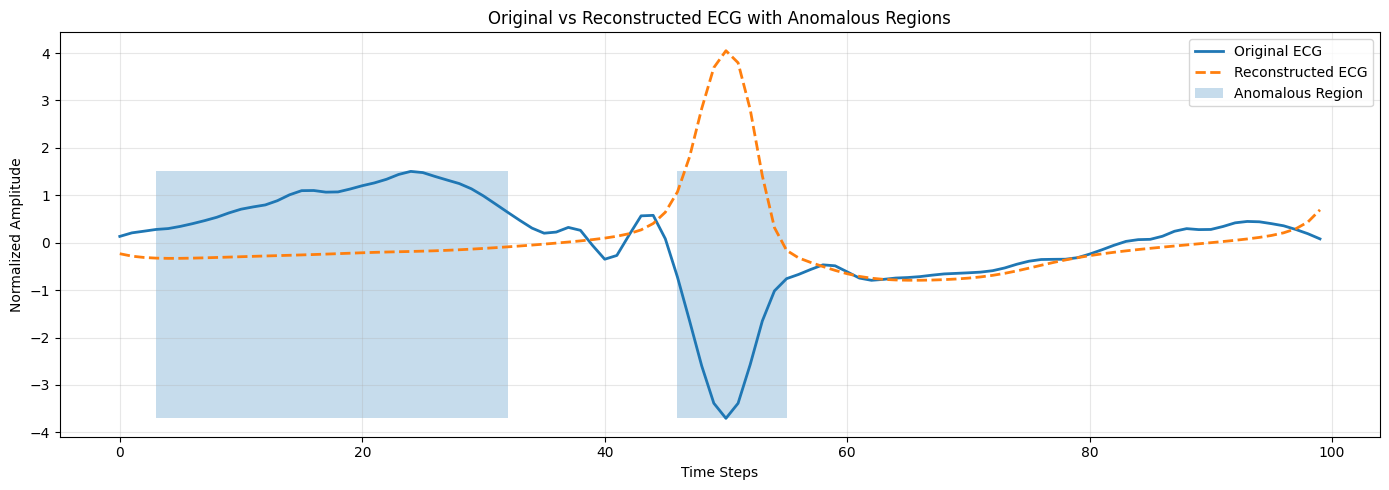

Selected class: Ventricular Ectopic
Reconstruction MSE: 2.955962
Threshold: 0.3275091


In [8]:
# ============================================================
# VISUAL OUTPUT 1
# Original vs Reconstructed ECG
# Highlight anomalous temporal regions
# ============================================================

# Select the highest-error VPC beat
vpc_indices = np.where(
    y_labels == "Ventricular Ectopic"
)[0]

selected_idx = vpc_indices[
    np.argmax(
        reconstruction_errors[vpc_indices]
    )
]

original = X_ecg[selected_idx]
reconstructed = reconstructed_all[selected_idx]

point_error = (
    original - reconstructed
) ** 2

anomaly_points = (
    point_error >
    threshold
)

plt.figure(figsize=(14, 5))

plt.plot(
    original,
    label="Original ECG",
    linewidth=2
)

plt.plot(
    reconstructed,
    label="Reconstructed ECG",
    linestyle="--",
    linewidth=2
)

# Highlight anomalous points
x = np.arange(SEQ_LEN)

plt.fill_between(
    x,
    np.min(original),
    np.max(original),
    where=anomaly_points,
    alpha=0.25,
    label="Anomalous Region"
)

plt.title(
    "Original vs Reconstructed ECG with Anomalous Regions"
)

plt.xlabel("Time Steps")
plt.ylabel("Normalized Amplitude")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{BASE}/outputs/figures/"
    "original_vs_reconstructed_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Selected class:",
    y_labels[selected_idx]
)

print(
    "Reconstruction MSE:",
    reconstruction_errors[selected_idx]
)

print(
    "Threshold:",
    threshold
)

#Recurrent TimeGAN-Style WGAN

In [9]:
# ============================================================
# RECURRENT TIME-SERIES GAN
# WASSERSTEIN ADVERSARIAL TRAINING
# ============================================================

class Generator(nn.Module):

    def __init__(
        self,
        noise_dim=16,
        hidden_dim=32
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            noise_dim,
            hidden_dim,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, z):

        h, _ = self.lstm(z)

        return self.fc(h)


class Discriminator(nn.Module):

    def __init__(
        self,
        hidden_dim=32
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            1,
            hidden_dim,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        h, _ = self.lstm(x)

        last = h[:, -1, :]

        return self.fc(last)


# ------------------------------------------------------------
# VPC training data
# ------------------------------------------------------------

X_vpc = X_ecg[
    y_labels == "Ventricular Ectopic"
]

X_vpc = X_vpc[..., None]

print("Real VPC samples:", len(X_vpc))

vpc_loader = DataLoader(
    TensorDataset(
        torch.tensor(
            X_vpc,
            dtype=torch.float32
        )
    ),
    batch_size=64,
    shuffle=True,
    drop_last=True
)

G = Generator().to(DEVICE)

D = Discriminator().to(DEVICE)

g_optimizer = torch.optim.RMSprop(
    G.parameters(),
    lr=0.00005,
    weight_decay=1e-5
)

d_optimizer = torch.optim.RMSprop(
    D.parameters(),
    lr=0.00005,
    weight_decay=1e-5
)

NOISE_DIM = 16
GAN_EPOCHS = 1000

g_losses = []
d_losses = []

data_iter = iter(vpc_loader)

for epoch in range(GAN_EPOCHS):

    try:
        (real_batch,) = next(data_iter)
    except StopIteration:
        data_iter = iter(vpc_loader)
        (real_batch,) = next(data_iter)

    real_batch = real_batch.to(DEVICE)

    batch_size = real_batch.size(0)

    # ========================================================
    # Train Critic
    # ========================================================

    z = torch.randn(
        batch_size,
        SEQ_LEN,
        NOISE_DIM,
        device=DEVICE
    )

    fake_batch = G(z).detach()

    real_score = D(real_batch)
    fake_score = D(fake_batch)

    d_loss = (
        fake_score.mean()
        -
        real_score.mean()
    )

    d_optimizer.zero_grad()

    d_loss.backward()

    d_optimizer.step()

    # Weight clipping for WGAN
    for p in D.parameters():
        p.data.clamp_(
            -0.01,
            0.01
        )

    # ========================================================
    # Train Generator
    # ========================================================

    z = torch.randn(
        batch_size,
        SEQ_LEN,
        NOISE_DIM,
        device=DEVICE
    )

    fake_batch = G(z)

    fake_score = D(fake_batch)

    g_loss = -fake_score.mean()

    g_optimizer.zero_grad()

    g_loss.backward()

    g_optimizer.step()

    g_losses.append(
        g_loss.item()
    )

    d_losses.append(
        d_loss.item()
    )

    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch {epoch+1}/{GAN_EPOCHS} | "
            f"G Loss: {g_loss.item():.6f} | "
            f"D Loss: {d_loss.item():.6f}"
        )

# Save models
torch.save(
    G.state_dict(),
    f"{BASE}/outputs/models/timegan_generator.pth"
)

torch.save(
    D.state_dict(),
    f"{BASE}/outputs/models/timegan_discriminator.pth"
)

print("\n1,000-epoch adversarial training complete.")

Real VPC samples: 942
Epoch 100/1000 | G Loss: 0.000525 | D Loss: -0.000025
Epoch 200/1000 | G Loss: 0.000468 | D Loss: -0.000046
Epoch 300/1000 | G Loss: 0.000488 | D Loss: -0.000094
Epoch 400/1000 | G Loss: 0.000414 | D Loss: -0.000121
Epoch 500/1000 | G Loss: 0.000188 | D Loss: -0.000194
Epoch 600/1000 | G Loss: -0.000174 | D Loss: -0.000178
Epoch 700/1000 | G Loss: -0.000707 | D Loss: -0.000181
Epoch 800/1000 | G Loss: -0.001228 | D Loss: -0.000098
Epoch 900/1000 | G Loss: -0.001062 | D Loss: 0.000082
Epoch 1000/1000 | G Loss: -0.000186 | D Loss: 0.000019

1,000-epoch adversarial training complete.


#Save Losses + Required Loss Curve

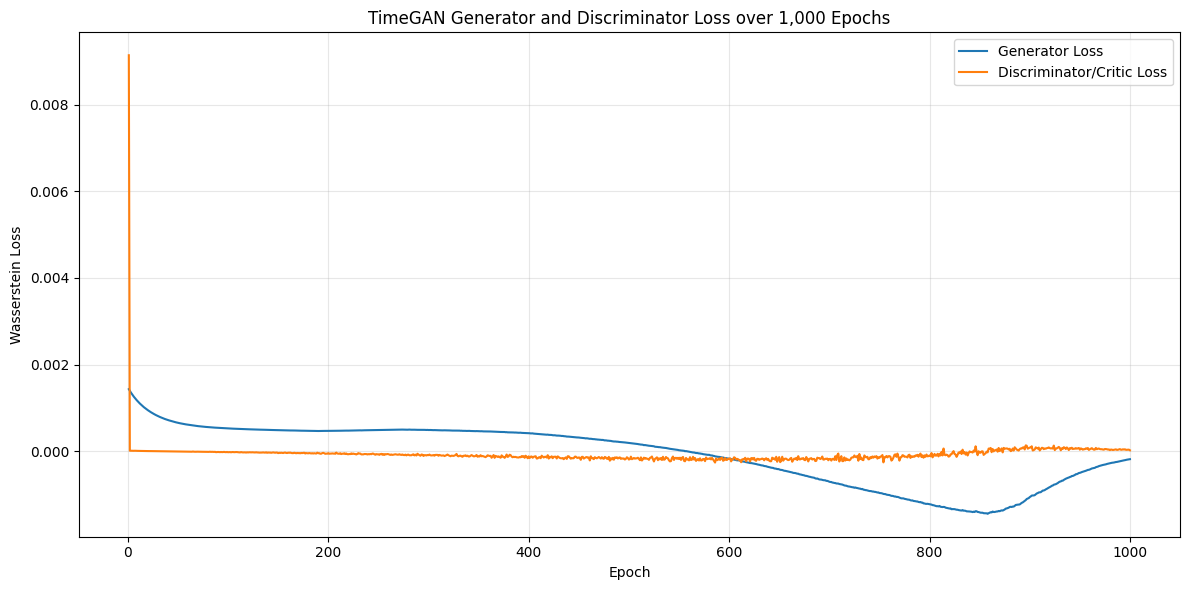

Loss curve saved.


In [10]:
# ============================================================
# TIMEGAN LOSS CURVE
# ============================================================

loss_df = pd.DataFrame({
    "epoch": np.arange(
        1,
        GAN_EPOCHS + 1
    ),
    "generator_loss": g_losses,
    "discriminator_loss": d_losses
})

loss_df.to_csv(
    f"{BASE}/outputs/results/timegan_losses.csv",
    index=False
)

plt.figure(figsize=(12, 6))

plt.plot(
    loss_df["epoch"],
    loss_df["generator_loss"],
    label="Generator Loss"
)

plt.plot(
    loss_df["epoch"],
    loss_df["discriminator_loss"],
    label="Discriminator/Critic Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Wasserstein Loss")

plt.title(
    "TimeGAN Generator and Discriminator Loss "
    "over 1,000 Epochs"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{BASE}/outputs/figures/timegan_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss curve saved.")

#Generate 1,000 Synthetic VPC ECGs

In [11]:
# ============================================================
# SYNTHETIC ECG GENERATION
# ============================================================

G.eval()

SYNTHETIC_COUNT = 1000

synthetic_list = []

with torch.no_grad():

    for start in range(
        0,
        SYNTHETIC_COUNT,
        100
    ):

        current_batch = min(
            100,
            SYNTHETIC_COUNT - start
        )

        z = torch.randn(
            current_batch,
            SEQ_LEN,
            NOISE_DIM,
            device=DEVICE
        )

        fake = G(z)

        fake = (
            fake
            .cpu()
            .numpy()
            .squeeze(-1)
        )

        synthetic_list.append(fake)


X_synthetic_vpc = np.concatenate(
    synthetic_list,
    axis=0
)

print(
    "Synthetic VPC shape:",
    X_synthetic_vpc.shape
)

np.save(
    f"{BASE}/data/processed/"
    "X_synthetic_vpc.npy",
    X_synthetic_vpc
)

Synthetic VPC shape: (1000, 100)


#Required Real vs Synthetic ECG Figure

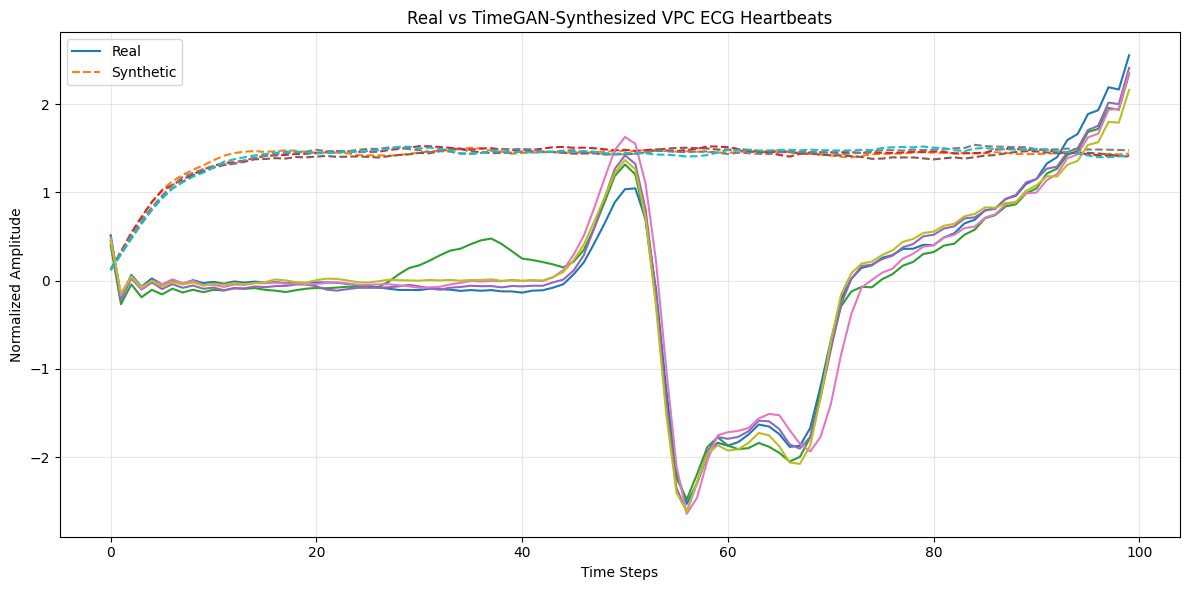

In [12]:
# ============================================================
# VISUAL OUTPUT 2
# REAL VS SYNTHETIC ECG
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(5):

    plt.plot(
        X_vpc[i],
        linewidth=1.5,
        label="Real" if i == 0 else None
    )

    plt.plot(
        X_synthetic_vpc[i],
        linestyle="--",
        linewidth=1.5,
        label="Synthetic" if i == 0 else None
    )

plt.title(
    "Real vs TimeGAN-Synthesized VPC ECG Heartbeats"
)

plt.xlabel("Time Steps")
plt.ylabel("Normalized Amplitude")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{BASE}/outputs/figures/"
    "real_vs_synthetic_ecg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#DTW

In [13]:
# ============================================================
# DTW EVALUATION
# ============================================================

def dtw_distance(a, b):

    n = len(a)
    m = len(b)

    matrix = np.full(
        (n + 1, m + 1),
        np.inf
    )

    matrix[0, 0] = 0

    for i in range(1, n + 1):

        for j in range(1, m + 1):

            cost = abs(
                a[i - 1] -
                b[j - 1]
            )

            matrix[i, j] = cost + min(
                matrix[i - 1, j],
                matrix[i, j - 1],
                matrix[i - 1, j - 1]
            )

    return matrix[n, m]


DTW_EVAL = 100

dtw_values = []

for i in range(DTW_EVAL):

    dtw_values.append(
        dtw_distance(
            X_vpc[i],
            X_synthetic_vpc[i]
        )
    )

mean_dtw = np.mean(dtw_values)

print(
    f"Mean Real-vs-Synthetic DTW "
    f"({DTW_EVAL} pairs): "
    f"{mean_dtw:.6f}"
)

pd.DataFrame({
    "dtw_distance": dtw_values
}).to_csv(
    f"{BASE}/outputs/results/dtw_results.csv",
    index=False
)

/tmp/ipykernel_2407/2438002594.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  matrix[i, j] = cost + min(


Mean Real-vs-Synthetic DTW (100 pairs): 57.089264


#LSTM Classifier

In [14]:
# ============================================================
# DOWNSTREAM LSTM CLASSIFIER
# ============================================================

classes = [
    "Normal",
    "Supraventricular Ectopic",
    "Ventricular Ectopic",
    "Fusion",
    "Unknown"
]

label_to_id = {
    label: i
    for i, label in enumerate(classes)
}

y_numeric = np.array([
    label_to_id[label]
    for label in y_labels
])

X_classifier = X_ecg[..., None]


class LSTMClassifier(nn.Module):

    def __init__(
        self,
        input_dim=1,
        hidden_dim=64,
        num_classes=5
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(
                hidden_dim,
                32
            ),
            nn.ReLU(),
            nn.Linear(
                32,
                num_classes
            )
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        return self.fc(
            output[:, -1, :]
        )


def train_classifier(
    X_train,
    y_train,
    epochs=15
):

    model = LSTMClassifier().to(DEVICE)

    loader = DataLoader(
        TensorDataset(
            torch.tensor(
                X_train,
                dtype=torch.float32
            ),
            torch.tensor(
                y_train,
                dtype=torch.long
            )
        ),
        batch_size=128,
        shuffle=True
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-5
    )

    for epoch in range(epochs):

        model.train()

        for xb, yb in loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            output = model(xb)

            loss = criterion(
                output,
                yb
            )

            loss.backward()

            optimizer.step()

    return model


# ------------------------------------------------------------
# SAME stratified split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_classifier,
    y_numeric,
    test_size=0.20,
    random_state=SEED,
    stratify=y_numeric
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8033
Testing samples: 2009


#LSTM Real Imbalanced Accuracy

In [15]:
# ============================================================
# LSTM BASELINE
# ============================================================

lstm_real = train_classifier(
    X_train,
    y_train
)

lstm_real.eval()

with torch.no_grad():

    predictions = torch.argmax(
        lstm_real(
            torch.tensor(
                X_test,
                dtype=torch.float32
            ).to(DEVICE)
        ),
        dim=1
    ).cpu().numpy()

lstm_real_accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "LSTM Imbalanced Accuracy:",
    lstm_real_accuracy
)

torch.save(
    lstm_real.state_dict(),
    f"{BASE}/outputs/models/"
    "lstm_classifier_real.pth"
)

LSTM Imbalanced Accuracy: 0.9522150323544052


#LSTM + GAN Augmentation

In [16]:
# ============================================================
# LSTM + GAN AUGMENTATION
# ============================================================

synthetic_labels = np.full(
    len(X_synthetic_vpc),
    label_to_id["Ventricular Ectopic"]
)

X_train_aug = np.concatenate(
    [
        X_train,
        X_synthetic_vpc[..., None]
    ],
    axis=0
)

y_train_aug = np.concatenate(
    [
        y_train,
        synthetic_labels
    ],
    axis=0
)

print(
    "Augmented training samples:",
    len(X_train_aug)
)

lstm_aug = train_classifier(
    X_train_aug,
    y_train_aug
)

lstm_aug.eval()

with torch.no_grad():

    predictions_aug = torch.argmax(
        lstm_aug(
            torch.tensor(
                X_test,
                dtype=torch.float32
            ).to(DEVICE)
        ),
        dim=1
    ).cpu().numpy()

lstm_aug_accuracy = accuracy_score(
    y_test,
    predictions_aug
)

print(
    "LSTM GAN-Augmented Accuracy:",
    lstm_aug_accuracy
)

torch.save(
    lstm_aug.state_dict(),
    f"{BASE}/outputs/models/"
    "lstm_classifier_gan_augmented.pth"
)

Augmented training samples: 9033
LSTM GAN-Augmented Accuracy: 0.9661523145843703


#Simple RNN Baseline

In [17]:
# ============================================================
# SIMPLE RNN CLASSIFIER
# ============================================================

class SimpleRNNClassifier(nn.Module):

    def __init__(
        self,
        input_dim=1,
        hidden_dim=64,
        num_classes=5
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_dim,
            hidden_dim,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(
                hidden_dim,
                32
            ),
            nn.ReLU(),
            nn.Linear(
                32,
                num_classes
            )
        )

    def forward(self, x):

        output, _ = self.rnn(x)

        return self.fc(
            output[:, -1, :]
        )


def train_rnn(
    X_train,
    y_train,
    epochs=15
):

    model = SimpleRNNClassifier().to(DEVICE)

    loader = DataLoader(
        TensorDataset(
            torch.tensor(
                X_train,
                dtype=torch.float32
            ),
            torch.tensor(
                y_train,
                dtype=torch.long
            )
        ),
        batch_size=128,
        shuffle=True
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-5
    )

    for epoch in range(epochs):

        model.train()

        for xb, yb in loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            output = model(xb)

            loss = criterion(
                output,
                yb
            )

            loss.backward()

            optimizer.step()

    return model


rnn_real = train_rnn(
    X_train,
    y_train
)

rnn_real.eval()

with torch.no_grad():

    rnn_predictions = torch.argmax(
        rnn_real(
            torch.tensor(
                X_test,
                dtype=torch.float32
            ).to(DEVICE)
        ),
        dim=1
    ).cpu().numpy()

rnn_real_accuracy = accuracy_score(
    y_test,
    rnn_predictions
)

print(
    "Simple RNN Accuracy:",
    rnn_real_accuracy
)

Simple RNN Accuracy: 0.9352911896465903


#Simple RNN + GAN Augmentation

In [18]:
# ============================================================
# SIMPLE RNN + GAN AUGMENTATION
# ============================================================

rnn_aug = train_rnn(
    X_train_aug,
    y_train_aug
)

rnn_aug.eval()

with torch.no_grad():

    rnn_aug_predictions = torch.argmax(
        rnn_aug(
            torch.tensor(
                X_test,
                dtype=torch.float32
            ).to(DEVICE)
        ),
        dim=1
    ).cpu().numpy()

rnn_aug_accuracy = accuracy_score(
    y_test,
    rnn_aug_predictions
)

print(
    "Simple RNN GAN-Augmented Accuracy:",
    rnn_aug_accuracy
)

Simple RNN GAN-Augmented Accuracy: 0.9397710303633648


#FINAL COMPARISON TABLE

In [19]:
# ============================================================
# FINAL RESULTS TABLE
# ============================================================

results = pd.DataFrame({

    "Model Approach": [
        "Standard Simple RNN",
        "LSTM-Autoencoder",
        "Hybrid TimeGAN + LSTM Classifier"
    ],

    "Reconstruction MSE": [
        np.nan,
        reconstruction_errors.mean(),
        np.nan
    ],

    "DTW Distance": [
        mean_dtw,
        np.nan,
        mean_dtw
    ],

    "Classification Accuracy (Imbalanced)": [
        rnn_real_accuracy,
        np.nan,
        lstm_real_accuracy
    ],

    "Classification Accuracy (GAN Augmented)": [
        rnn_aug_accuracy,
        np.nan,
        lstm_aug_accuracy
    ],

    "GitHub Repository Hash": [
        "TBD",
        "TBD",
        "TBD"
    ]
})

print(
    results.to_string(
        index=False
    )
)

results.to_csv(
    f"{BASE}/outputs/results/"
    "master_results.csv",
    index=False
)

print(
    "\nFinal comparison table saved."
)

                  Model Approach  Reconstruction MSE  DTW Distance  Classification Accuracy (Imbalanced)  Classification Accuracy (GAN Augmented) GitHub Repository Hash
             Standard Simple RNN                 NaN     57.089264                              0.935291                                 0.939771                    TBD
                LSTM-Autoencoder            0.249899           NaN                                   NaN                                      NaN                    TBD
Hybrid TimeGAN + LSTM Classifier                 NaN     57.089264                              0.952215                                 0.966152                    TBD

Final comparison table saved.


#Final Dataset Summary

In [20]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("CARDIOSYNTH-LSTM FINAL SUMMARY")
print("=" * 70)

print("Total real ECG beats:", len(X_ecg))

print(
    "Sequence length:",
    SEQ_LEN
)

print(
    "\nClass distribution:"
)

print(
    pd.Series(y_labels).value_counts()
)

print(
    "\nReal VPC samples:",
    len(X_vpc)
)

print(
    "Synthetic VPC samples:",
    len(X_synthetic_vpc)
)

print(
    "\nLSTM-AE Reconstruction MSE:",
    reconstruction_errors.mean()
)

print(
    "Anomaly threshold:",
    threshold
)

print(
    "\nMean real-vs-synthetic DTW:",
    mean_dtw
)

print(
    "\nSimple RNN Accuracy:",
    rnn_real_accuracy
)

print(
    "Simple RNN + GAN Accuracy:",
    rnn_aug_accuracy
)

print(
    "\nLSTM Accuracy:",
    lstm_real_accuracy
)

print(
    "LSTM + GAN Accuracy:",
    lstm_aug_accuracy
)

print("\nAll results and figures saved.")

CARDIOSYNTH-LSTM FINAL SUMMARY
Total real ECG beats: 10042
Sequence length: 100

Class distribution:
Normal                      8786
Ventricular Ectopic          942
Supraventricular Ectopic     295
Fusion                        15
Unknown                        4
Name: count, dtype: int64

Real VPC samples: 942
Synthetic VPC samples: 1000

LSTM-AE Reconstruction MSE: 0.24989948
Anomaly threshold: 0.3275091

Mean real-vs-synthetic DTW: 57.08926448132843

Simple RNN Accuracy: 0.9352911896465903
Simple RNN + GAN Accuracy: 0.9397710303633648

LSTM Accuracy: 0.9522150323544052
LSTM + GAN Accuracy: 0.9661523145843703

All results and figures saved.
